# Spotify Hit Predictor

## Exploratory Data Analysis

**Objective:** examine how audio features distribute and relate to popularity, and test whether engineered "cohesion" features outperform individual variables.

**Input:** `tracks_clean.csv` — 112,782 rows (output of notebook 01), deduplicated here to 89,023 unique tracks.

**Hit threshold:** popularity ≥ 70 (established in notebook 02, Q14).

### Hypotheses tested here

- **H1** — a detectable popularity pattern exists across audio features, regardless of genre.
- **H3** — engineered features capturing how audio elements *interact* (contrast, tension, impact) improve prediction over individual variables alone.

H2 (genre is secondary) is formally tested in Week 4, where the model runs with and without `track_genre` 


In [33]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('../data/tracks_clean.csv')

## Deduplication for correlation analysis
Audio features (energy, danceability, valence, etc.) are fixed per track_id 
they don't change across genre-tag copies. Keeping duplicates would let 
multi-tagged songs (21% of rows, per Week 2 Q10) disproportionately influence 
the correlation matrix.

**Decision:** deduplicated by track_id (keep='first') before running EDA. 
`track_genre` is excluded from this analysis, its surviving value after 
deduplication would be arbitrary (CSV is alphabetically ordered by genre 
blocks), not meaningful. 

In [34]:
df_unique = df.drop_duplicates(subset='track_id', keep='first').copy()
print('Original rows:', df.shape[0])
print('Unique songs:', df_unique.shape[0])

print("Remaining duplicate track_ids:", df_unique['track_id'].duplicated().sum())

Original rows: 112782
Unique songs: 89023
Remaining duplicate track_ids: 0


## Q17 — How is popularity distributed?


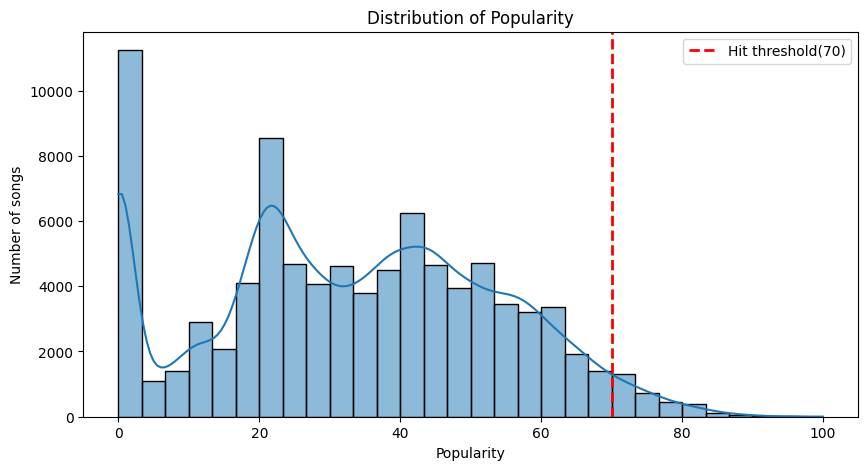

In [62]:
plt.figure(figsize=(10, 5))
sns.histplot(df_unique['popularity'], bins=30, kde=True)
plt.axvline(x=70, color='red', linestyle='--', linewidth=2, label='Hit threshold(70)')
plt.title('Distribution of Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of songs')
plt.legend()
plt.show()

In [ ]:

peak2 = df_unique[(df_unique['popularity'] >= 20) & (df_unique['popularity'] <= 25)]
print('Songs in this range:', peak2.shape[0])
print('\nTop genres in this range:')
print(peak2['track_genre'].value_counts().head(10))

Songs in this range: 11756

Top genres in this range:
track_genre
comedy         762
bluegrass      634
power-pop      597
heavy-metal    553
new-age        503
goth           495
opera          495
hardstyle      489
death-metal    445
industrial     442
Name: count, dtype: int64


In [ ]:
peak3 = df_unique[(df_unique['popularity'] >= 40) & (df_unique['popularity'] <= 50)]
print('Songs in this range:', peak3.shape[0])
print('\nTop genres in this range:')
print(peak3['track_genre'].value_counts().head(10))


Songs in this range: 16118

Top genres in this range:
track_genre
brazil         800
pagode         729
sertanejo      651
mpb            625
forro          605
turkish        496
world-music    440
dub            394
funk           390
indian         386
Name: count, dtype: int64


In [ ]:
peak_70 = df_unique[(df_unique['popularity'] >= 70) ]
print('Songs in this range:', peak_70.shape[0])
print('\nTop genres in this range:')
print(peak_70['track_genre'].value_counts().head(10))


Songs in this range: 3124

Top genres in this range:
track_genre
dance        243
k-pop        213
alt-rock     165
latino       140
electro      130
indie-pop    126
hip-hop      118
edm          114
pop          108
hard-rock    103
Name: count, dtype: int64


### Popularity distribution
Multimodal, not a smooth curve: a massive spike at 0 (~11,000 songs
consistent with the "87% never reach 1,000 streams" business problem), 
followed by smaller peaks around 20-25 and 40-50, then a long thin tail 
toward 100.

**Peak at 20-25 investigation:** checked niche genres landing here 
(comedy, bluegrass, power-pop, heavy-metal, opera, death-metal). No 
single genre dominates, most individual genres simply have a naturally 
low-to-moderate popularity ceiling.

**Peak at 40-50 investigation:** dominated by Brazilian/Latin genres:
brazil (800), pagode (729), sertanejo (651), mpb (625), forro (605). 
Unlike the 20-25 peak (scattered niche genres), this 
peak reflects a cohesive market: Brazilian music genres (several of which 
overlap on the same tracks, per the Q7 finding that "brazil" is a 
country-tag, not a sound-genre).

**Peak at 70+ (true hits):** dominated by mainstream, high-energy 
genres: dance (243), k-pop (213), alt-rock (165), latino (140), electro 
(130), hip-hop (118), edm (114).

**Across all three zones, a progression emerges:**
- 20-25: scattered niche genres, no unifying sound
- 40-50: a cohesive regional market (Brazilian/Latin), unified by 
  audience, not necessarily by audio profile
- 70+: mainstream, beat-driven genres. The closest thing to a unifying 
  sound, consistent with H1's core intuition


## Q16 — Which audio features correlate most with popularity?


In [66]:
audio_features = ['popularity', 'danceability', 'energy', 'loudness', 
                   'speechiness', 'acousticness', 'instrumentalness', 
                   'liveness', 'valence', 'tempo', 'duration_ms']

correlations = df_unique[audio_features].corr()
correlations

,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
popularity,1.000000,0.064663,0.012448,0.069640,-0.046543,-0.038047,-0.124743,-0.014346,-0.013955,0.007572,-0.007902
danceability,0.064663,1.000000,0.130907,0.258444,0.106971,-0.174298,-0.186241,-0.127026,0.486012,-0.047483,-0.061241
energy,0.012448,0.130907,1.000000,0.758903,0.139784,-0.735950,-0.175436,0.195698,0.249762,0.248204,0.102287
loudness,0.069640,0.258444,0.758903,1.000000,0.053144,-0.585176,-0.431301,0.083426,0.280999,0.213939,0.033787
speechiness,-0.046543,0.106971,0.139784,0.053144,1.000000,0.003325,-0.097165,0.225402,0.031075,-0.000145,-0.091978
acousticness,-0.038047,-0.174298,-0.735950,-0.585176,0.003325,1.000000,0.094915,-0.021473,-0.101910,-0.219266,-0.161885
instrumentalness,-0.124743,-0.186241,-0.175436,-0.431301,-0.097165,0.094915,1.000000,-0.091554,-0.325244,-0.046192,0.123984
liveness,-0.014346,-0.127026,0.195698,0.083426,0.225402,-0.021473,-0.091554,1.000000,0.016675,0.003114,0.002981
valence,-0.013955,0.486012,0.249762,0.280999,0.031075,-0.101910,-0.325244,0.016675,1.000000,0.078412,-0.175008
tempo,0.007572,-0.047483,0.248204,0.213939,-0.000145,-0.219266,-0.046192,0.003114,0.078412,1.000000,0.037040


Computed Pearson correlation across all numeric audio features. No single 
feature correlates strongly: loudness 0.07, danceability 0.06, energy 
0.01, tempo 0.01, valence -0.01, acousticness -0.04, instrumentalness 
-0.12 (weakest but strongest of the group).

**Q18 note (energy/loudness redundancy):** the two correlate strongly 
with *each other* (0.76) — along with energy-acousticness (-0.74) — but 
neither predicts popularity directly.

**Finding:** no individual feature is a strong predictor on its own. This 
motivates testing the hits-only subgroup next.

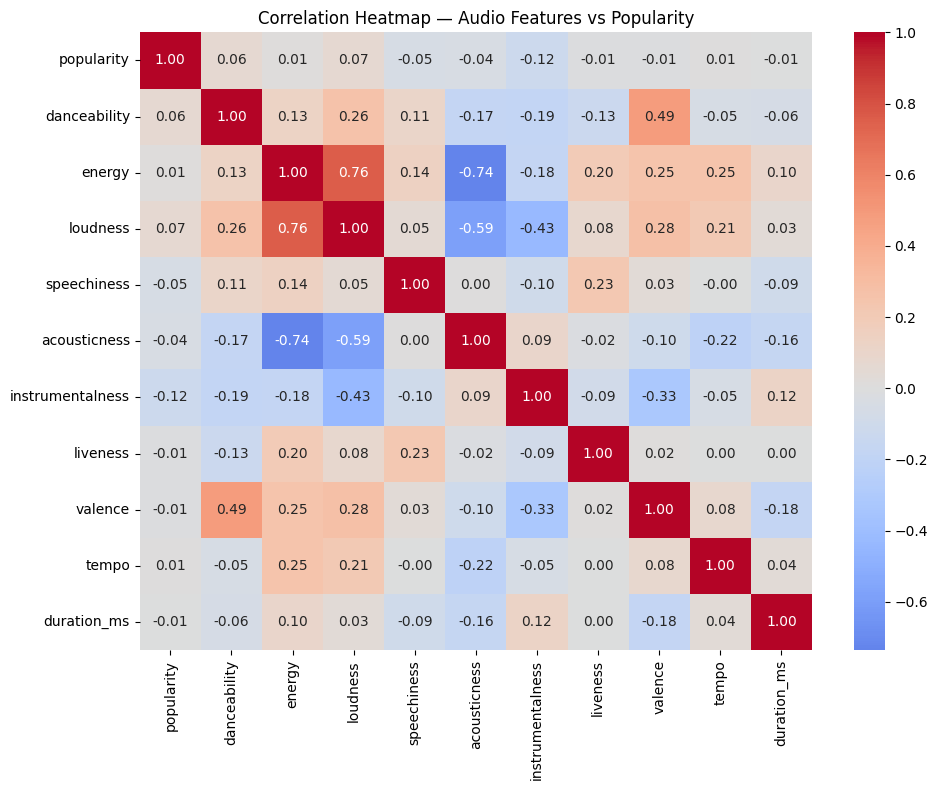

In [67]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Audio Features vs Popularity')
plt.tight_layout()
plt.show()

In [ ]:
hits = df_unique[df_unique['popularity'] >= 70]
no_hits = df_unique[df_unique['popularity'] < 70]

print("--- HITS (popularity >= 70) ---")
print("Energy avg:", hits['energy'].mean().round(3))
print("Danceability avg:", hits['danceability'].mean().round(3))

print("\n--- NO HITS (popularity < 70) ---")
print("Energy avg:", no_hits['energy'].mean().round(3))
print("Danceability avg:", no_hits['danceability'].mean().round(3))

--- HITS (popularity >= 70) ---
Energy promedio: 0.664
Danceability promedio: 0.622

--- NO HITS (popularity < 70) ---
Energy promedio: 0.635
Danceability promedio: 0.562


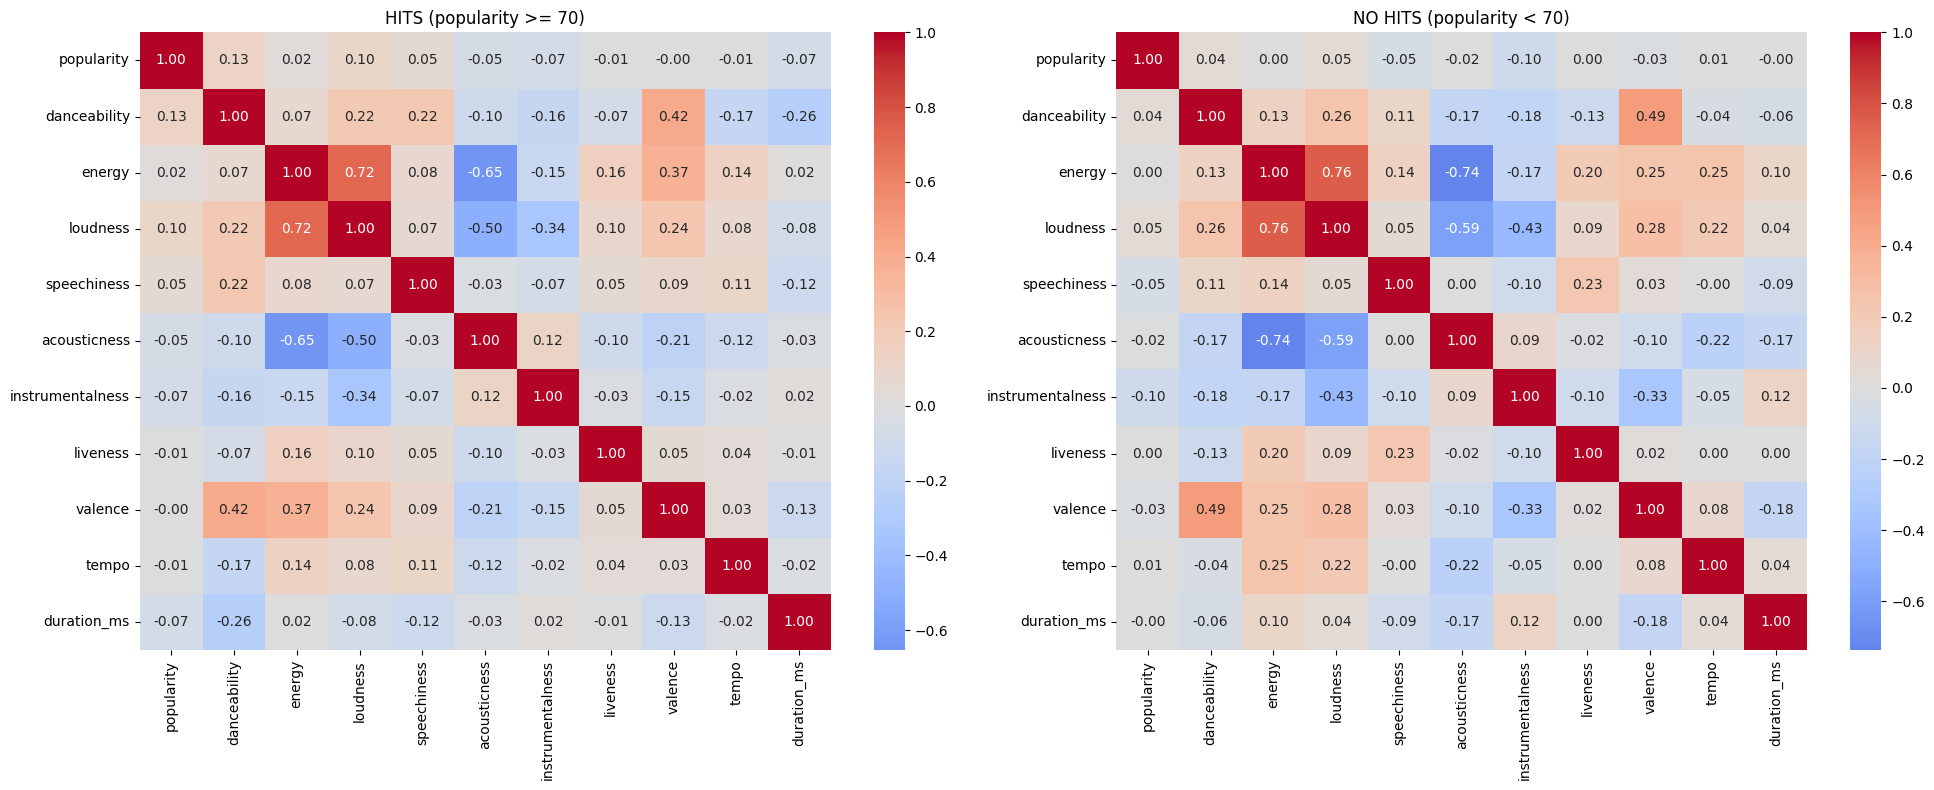

In [69]:
hits = df_unique[df_unique['popularity'] >= 70]
no_hits = df_unique[df_unique['popularity'] < 70]

audio_features = ['popularity', 'danceability', 'energy', 'loudness', 
                   'speechiness', 'acousticness', 'instrumentalness', 
                   'liveness', 'valence', 'tempo', 'duration_ms']

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(hits[audio_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('HITS (popularity >= 70)')

sns.heatmap(no_hits[audio_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, ax=axes[1])
axes[1].set_title('NO HITS (popularity < 70)')

plt.tight_layout()
plt.show()

## Digging deeper — does the pattern strengthen inside the hits group?

Split at the hit threshold (popularity >= 70) and compared feature 
averages and correlation structure between groups.

**Averages:** energy 0.664 (hits) vs 0.635 (non-hits); danceability 0.622 
vs 0.562 — real but modest gaps.

**Correlation shifts inside hits:** danceability-popularity triples (0.04 
→ 0.13); energy-valence strengthens (0.25 → 0.37).

**Finding:** features move more tightly together within the hits group
indirect quantitative evidence for H3.

In [70]:
df_unique['contrast'] = df_unique['energy'] * (1 - df_unique['acousticness'])
df_unique['tension'] = (1 - df_unique['valence']) * df_unique['energy']
df_unique['impact'] = df_unique['energy'] * df_unique['danceability'] * (df_unique['loudness'] + 60) / 60

### Engineered Features — Why and How

The raw audio features measure isolated properties of a song, but the 
project's core hypothesis (H3) is that hits are driven by *how features 
interact*, not by any single variable in isolation. These three features 
are constructed by **multiplying** — not adding — component variables, 
so that a high score requires all conditions to hold simultaneously. 
Multiplication rewards cohesion; addition would just reward accumulation.

### contrast = energy × (1 − acousticness)
Captures how "produced/electric" a song feels versus "stripped down." 
`(1 − acousticness)` flips the acoustic score so it represents 
*non-acousticness* — high when a track relies on electronic/amplified 
production. Multiplying by energy means a song only scores high here if 
it's BOTH intense AND non-acoustic (e.g., EDM, rock) — a highly energetic 
but heavily acoustic track (loud solo guitar) stays moderate, since the 
two conditions pull against each other.

### tension = (1 − valence) × energy
Captures "dark energy" versus "bright energy." Two songs can share the 
same energy score but feel emotionally opposite — aggressive trap vs. 
euphoric pop. `(1 − valence)` flips positivity into its opposite: how 
emotionally dark/tense a track is. Multiplying by energy ensures tension 
only registers when darkness is paired with intensity — a slow, sad, 
low-energy ballad isn't "tense," it's simply melancholic and calm.

### impact = energy × danceability × (loudness + 60) / 60
Captures the physical "hit" of a song — energy, rhythm, and volume acting 
together. All three factors are required at once; if any one is low, 
total impact drops. `loudness` is rescaled from its native range (−60 to 
0 dB) to 0–1 via `(loudness + 60) / 60`, so it's on the same scale as 
the other 0–1 features and multiplying doesn't produce negative results.

### Why multiplication, not addition
Every formula tests H3 directly: a hit isn't explained by one strong 
variable — it's explained by several variables reinforcing each other at 
once. Multiplication is the mathematical expression of that idea.

In [43]:
df_unique[['contrast', 'tension', 'impact']].describe()

,contrast,tension,impact
count,8.902300e+04,89023.000000,8.902300e+04
mean,4.912691e-01,0.319511,3.231251e-01
std,3.215871e-01,0.214891,1.677672e-01
min,1.212000e-07,0.000001,7.560620e-07
25%,1.844450e-01,0.152382,1.958044e-01
50%,5.122950e-01,0.278800,3.313774e-01
75%,7.833543e-01,0.443874,4.483622e-01
max,9.993500e-01,0.999990,9.671246e-01


In [44]:
engineered = ['popularity', 'contrast', 'tension', 'impact', 
              'danceability', 'energy', 'valence', 'acousticness']

df_unique[engineered].corr()['popularity']

popularity      1.000000
contrast        0.002676
tension         0.014485
impact          0.042112
danceability    0.064663
energy          0.012448
valence        -0.013955
acousticness   -0.038047
Name: popularity, dtype: float64

In [45]:
hits = df_unique[df_unique['popularity'] >= 70]

engineered = ['popularity', 'contrast', 'tension', 'impact', 
              'danceability', 'energy', 'valence', 'acousticness']

hits[engineered].corr()['popularity']

popularity      1.000000
contrast        0.025292
tension         0.018686
impact          0.099977
danceability    0.127937
energy          0.020647
valence        -0.000405
acousticness   -0.053464
Name: popularity, dtype: float64

## Engineered Features vs. Popularity — Results

Correlated contrast, tension, and impact against popularity, both across 
the full dataset and within the hits-only subgroup (popularity >= 70).

**Full dataset:** all three engineered features show near-zero correlation 
(contrast: 0.003, tension: 0.014, impact: 0.042) — weaker than the raw 
danceability feature alone (0.065).

**Hits-only subgroup:** all features strengthen, but danceability remains 
the strongest predictor (0.128) — even ahead of impact (0.100), the best-
performing engineered feature.

**Finding:** simple multiplicative combinations of already-correlated 
variables (e.g., energy × acousticness, which had a -0.74 correlation 
with each other) don't generate new signal — they approach, but don't 
exceed, the strength of their single strongest component. H3 is not 
supported by this specific engineering approach.

**Implication for Week 4:** hand-designed feature combinations underperform 
here. A machine learning model (e.g., Random Forest) may be better suited 
to discover non-linear or higher-order interactions between features than 
a fixed formula can — this becomes the real test of whether "cohesion" 
adds predictive value.

In [46]:
df_unique[['duration_ms', 'valence', 'acousticness', 'energy']].corr()['duration_ms']

duration_ms     1.000000
valence        -0.175008
acousticness   -0.161885
energy          0.102287
Name: duration_ms, dtype: float64

In [48]:
hits = df_unique[df_unique['popularity'] >= 70]

explicit_by_genre_hits = hits.groupby('track_genre')['explicit'].mean().sort_values(ascending=False)
print("Top 10 genres by explicit rate (HITS ONLY):")
print(explicit_by_genre_hits.head(10))

print("\nExplicit rate among hits:", hits['explicit'].mean().round(3))
print("Explicit rate among non-hits:", df_unique[df_unique['popularity'] < 70]['explicit'].mean().round(3))

Top 10 genres by explicit rate (HITS ONLY):
track_genre
club        1.000000
comedy      1.000000
hardcore    0.800000
r-n-b       0.727273
j-dance     0.666667
sad         0.625000
emo         0.560000
funk        0.555556
groove      0.500000
hip-hop     0.440678
Name: explicit, dtype: float64

Explicit rate among hits: 0.179
Explicit rate among non-hits: 0.083


### Carried from Week 2 (Q12) — does duration correlate with mood/production?

duration_ms shows weak-to-moderate correlations with valence (-0.175), 
acousticness (-0.161), and energy (0.102). Longer tracks skew slightly 
less "happy" and less acoustic — consistent with the qualitative Week 2 
finding that long-track hits (Kate Bush, The Weeknd, Eminem) leaned 
narrative/emotional rather than beat-driven. Weak correlations — a mild 
tendency, not a rule.

### Carried from Week 2 (Q15) — does the explicit effect survive genre control?

Explicit rate among hits: 17.9%. Among non-hits: 8.3% — more than double.
Top genres by explicit rate within hits: club/comedy (100%, small 
samples), r-n-b (72.7%), hip-hop (44.7%).

**Finding:** the effect holds under the hits filter but stays genre-
concentrated. Worth testing as a Week 4 model feature rather than 
dismissing as pure confounding.

In [49]:
hits = df_unique[df_unique['popularity'] >= 70]

full_features = ['popularity', 'danceability', 'energy', 'loudness', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo', 'duration_ms',
                  'key', 'mode']

hits[full_features].corr()['popularity'].sort_values(ascending=False)

popularity          1.000000
danceability        0.127937
loudness            0.103026
speechiness         0.051516
energy              0.020647
valence            -0.000405
key                -0.004492
tempo              -0.010680
liveness           -0.013304
mode               -0.022500
acousticness       -0.053464
instrumentalness   -0.065338
duration_ms        -0.073451
Name: popularity, dtype: float64

## Key and Mode vs. Popularity

Within the hits group: key (-0.004) and mode (-0.023) both show negligible 
correlation with popularity — the weakest of all tested features.

**Finding:** the specific musical key or major/minor mode does not 
meaningfully predict hit potential. This closes the tonality question 
raised in Week 2 — a song's key doesn't matter, but its overall emotional 
character (captured better by valence, tension) may still play a role, 
even if not through key/mode specifically.

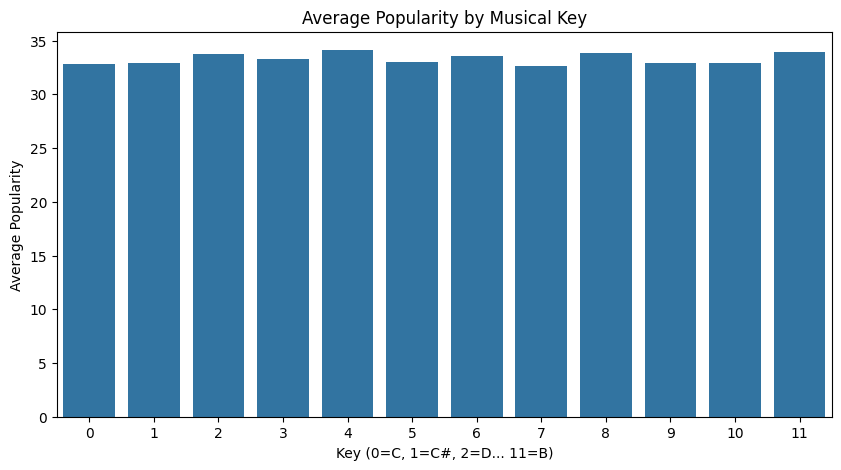

In [50]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_unique, x='key', y='popularity', errorbar=None)
plt.title('Average Popularity by Musical Key')
plt.xlabel('Key (0=C, 1=C#, 2=D... 11=B)')
plt.ylabel('Average Popularity')
plt.show()

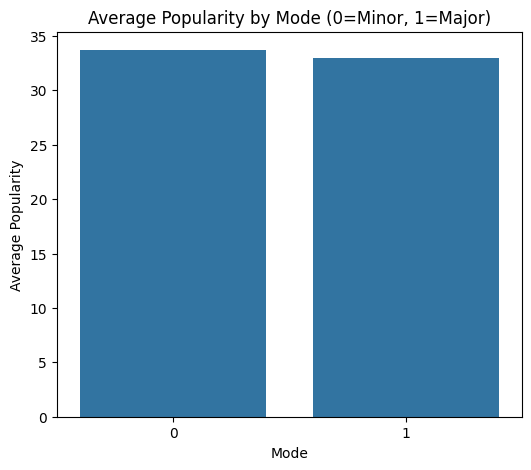

In [51]:
plt.figure(figsize=(6, 5))
sns.barplot(data=df_unique, x='mode', y='popularity', errorbar=None)
plt.title('Average Popularity by Mode (0=Minor, 1=Major)')
plt.xlabel('Mode')
plt.ylabel('Average Popularity')
plt.show()


## Summary — EDA Closed

**What was done:** deduplicated 112,782 rows to 89,023 unique tracks; 
investigated the full shape of `popularity` (including all three 
distribution peaks, each with a distinct explanation); computed the full 
correlation heatmap and compared it between hits and non-hits; built 3 
engineered features with deliberate multiplicative logic; closed the 
carried-over questions on duration, explicit content, key, and mode.

**Central finding:** no individual audio feature — original or engineered 
— predicts popularity strongly as a simple linear correlation. The pattern 
does activate consistently when narrowing to the hits group: features move 
more tightly together, danceability repeatedly emerges as the closest 
thing to a real signal, and the popularity distribution itself reveals 
distinct layers (scattered niche genres → a cohesive regional market → a 
unified mainstream sound at the very top).

### Hypothesis status

| Hypothesis | Verdict | Evidence |
|---|---|---|
| **H1** (pattern exists) | Partial | Weak as a general correlation; strengthens within the hits subgroup |
| **H2** (genre is secondary) | Pending | Formally tested in Week 4 |
| **H3** (cohesion matters) | Not supported this way | Multiplying already-correlated variables generated no new signal — an ML model is the next real test |

### This is a useful result, not a null one

No single feature turned out to be a magic predictor. What this notebook 
has instead is an honest investigation, with a documented turn (the 
engineered features that underperformed their own individual components) 
and a clear technical reason behind the result. Testing a hypothesis, 
having it fail as designed, understanding why, and using that to define 
the next step is the actual work of analysis.
